# 深度学习作业二：多层感知机

## 2.1 理论计算题

### 1. 非线性激活函数的重要性

**证明过程：**

将隐藏层表达式代入输出层：

$$o = W_2 h + b_2$$

将 $h = W_1 x + b_1$ 代入上式：

$$o = W_2 (W_1 x + b_1) + b_2 = W_2 W_1 x + W_2 b_1 + b_2$$

对比单层神经网络的一般形式 $o = W' x + b'$，可得：

$$W' = W_2 W_1$$

$$b' = W_2 b_1 + b_2$$

**结论：** 当隐藏层使用线性激活时，多层感知机退化为单层神经网络，无法学习非线性特征。

---

### 2. 激活函数性质分析

**Sigmoid 函数：**

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

导数：

$$\sigma'(x) = \sigma(x) (1 - \sigma(x))$$

**tanh 函数：**

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

导数：

$$\tanh'(x) = 1 - \tanh^2(x)$$

---

## 2.2 编程题：单隐藏层MLP实现

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

input_size = 784
hidden_size = 256
output_size = 10
batch_size = 64
learning_rate = 0.1
num_epochs = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

labels_map = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
              5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

print(f"训练集大小: {len(train_dataset)}, 测试集大小: {len(test_dataset)}")

训练集大小: 60000, 测试集大小: 10000


In [ ]:
np.random.seed(42)

W1 = torch.tensor(np.random.randn(input_size, hidden_size) * 0.01, dtype=torch.float32, device=device, requires_grad=True)
b1 = torch.tensor(np.zeros(hidden_size), dtype=torch.float32, device=device, requires_grad=True)
W2 = torch.tensor(np.random.randn(hidden_size, output_size) * 0.01, dtype=torch.float32, device=device, requires_grad=True)
b2 = torch.tensor(np.zeros(output_size), dtype=torch.float32, device=device, requires_grad=True)

print(f"W1: {W1.shape}, W2: {W2.shape}")

W1: torch.Size([784, 256]), W2: torch.Size([256, 10])


In [ ]:
def relu(x):
    return torch.max(torch.tensor(0.0, device=x.device), x)

def softmax(logits):
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    return exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)

def cross_entropy_loss(probs, labels):
    batch_size = probs.shape[0]
    log_probs = -torch.log(probs[range(batch_size), labels] + 1e-10)
    return torch.mean(log_probs)

def forward(x):
    z1 = torch.matmul(x, W1) + b1
    h1 = relu(z1)
    z2 = torch.matmul(h1, W2) + b2
    output = softmax(z2)
    return output, h1, z1

In [ ]:
print("开始训练...")
for epoch in range(num_epochs):
    total_loss, correct, total = 0.0, 0, 0
    for batch_idx, (images, labels_batch) in enumerate(train_loader):
        images = images.view(-1, input_size).to(device)
        labels_batch = labels_batch.to(device)

        outputs, _, _ = forward(images)
        loss = cross_entropy_loss(outputs, labels_batch)
        loss.backward()

        with torch.no_grad():
            W1 -= learning_rate * W1.grad
            b1 -= learning_rate * b1.grad
            W2 -= learning_rate * W2.grad
            b2 -= learning_rate * b2.grad
            W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}, Acc: {100*correct/total:.2f}%')

开始训练...
Epoch [1/10], Loss: 0.5657, Acc: 79.37%
Epoch [2/10], Loss: 0.4009, Acc: 85.42%
Epoch [3/10], Loss: 0.3597, Acc: 86.97%
Epoch [4/10], Loss: 0.3322, Acc: 87.75%
Epoch [5/10], Loss: 0.3142, Acc: 88.44%
Epoch [6/10], Loss: 0.2993, Acc: 88.93%
Epoch [7/10], Loss: 0.2848, Acc: 89.44%
Epoch [8/10], Loss: 0.2744, Acc: 89.89%
Epoch [9/10], Loss: 0.2622, Acc: 90.29%
Epoch [10/10], Loss: 0.2517, Acc: 90.74%


In [ ]:
test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.view(-1, input_size).to(device)
        labels_batch = labels_batch.to(device)
        outputs, _, _ = forward(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels_batch.size(0)
        test_correct += (predicted == labels_batch).sum().item()
print(f'测试准确率: {100 * test_correct / test_total:.2f}%')

测试准确率: 84.25%


---

# 3 模型选择，权重衰减和丢弃法

## 3.1 理论计算题

### 1. 过拟合与欠拟合

**训练误差 vs 泛化误差：**
- **训练误差**：模型在训练数据集上的误差
- **泛化误差**：模型在未见过的测试数据上的误差

**过拟合状态：**
当训练误差极低但泛化误差很高时，模型处于**过拟合**状态。

**缓解方法：**
1. 减少模型复杂度（网络层数、神经元数量）
2. L1/L2正则化
3. Dropout
4. 数据增强
5. 早停（Early Stopping）

---

### 2. K折交叉验证算法步骤

1. 将原始训练数据随机划分为K个大小相等的互斥子集
2. 对于第i折（i=1,2,...,K）：
   - 以第i折作为验证集
   - 其余K-1折合并作为训练集
   - 训练模型并在验证集上评估
3. 计算K次验证结果的平均值作为最终性能估计

---

## 3.2 编程题：L2正则化与Dropout

In [ ]:
weight_decay_lambda = 0.01
dropout_prob = 0.5

def dropout_layer(X, dropout, is_training=True):
    if not is_training:
        return X
    mask = (torch.rand(X.shape, device=X.device) > dropout).float()
    return mask * X / (1.0 - dropout)

def forward_with_dropout(x, W1, b1, W2, b2, is_training=True):
    z1 = torch.matmul(x, W1) + b1
    h1 = relu(z1)
    h1_dropout = dropout_layer(h1, dropout_prob, is_training)
    z2 = torch.matmul(h1_dropout, W2) + b2
    return softmax(z2)

In [ ]:
def train_model(use_weight_decay=False, use_dropout=False, num_epochs=15):
    np.random.seed(42)
    W1 = torch.tensor(np.random.randn(input_size, hidden_size) * 0.01, dtype=torch.float32, device=device, requires_grad=True)
    b1 = torch.tensor(np.zeros(hidden_size), dtype=torch.float32, device=device, requires_grad=True)
    W2 = torch.tensor(np.random.randn(hidden_size, output_size) * 0.01, dtype=torch.float32, device=device, requires_grad=True)
    b2 = torch.tensor(np.zeros(output_size), dtype=torch.float32, device=device, requires_grad=True)

    train_loss_history, val_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = 0.0
        for images, labels_batch in train_loader:
            images = images.view(-1, input_size).to(device)
            labels_batch = labels_batch.to(device)

            if use_dropout:
                outputs = forward_with_dropout(images, W1, b1, W2, b2, True)
            else:
                z1 = torch.matmul(images, W1) + b1
                h1 = relu(z1)
                z2 = torch.matmul(h1, W2) + b2
                outputs = softmax(z2)
            loss = cross_entropy_loss(outputs, labels_batch)
            loss.backward()

            with torch.no_grad():
                if use_weight_decay:
                    W1 = (W1 * (1 - learning_rate * weight_decay_lambda)) - learning_rate * W1.grad
                    W2 = (W2 * (1 - learning_rate * weight_decay_lambda)) - learning_rate * W2.grad
                else:
                    W1 -= learning_rate * W1.grad
                    W2 -= learning_rate * W2.grad
                b1 -= learning_rate * b1.grad
                b2 -= learning_rate * b2.grad

                W1 = W1.clone().requires_grad_(True)
                W2 = W2.clone().requires_grad_(True)
                b1 = b1.clone().requires_grad_(True)
                b2 = b2.clone().requires_grad_(True)

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        val_loss = 0.0
        with torch.no_grad():
            for images, labels_batch in test_loader:
                images = images.view(-1, input_size).to(device)
                labels_batch = labels_batch.to(device)
                if use_dropout:
                    outputs = forward_with_dropout(images, W1, b1, W2, b2, False)
                else:
                    z1 = torch.matmul(images, W1) + b1
                    h1 = relu(z1)
                    z2 = torch.matmul(h1, W2) + b2
                    outputs = softmax(z2)
                val_loss += cross_entropy_loss(outputs, labels_batch).item()

        avg_val_loss = val_loss / len(test_loader)
        val_loss_history.append(avg_val_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return train_loss_history, val_loss_history

In [ ]:
print('=' * 50)
print('实验1: 无正则化')
print('=' * 50)
train_loss_no_reg, val_loss_no_reg = train_model(use_weight_decay=False, use_dropout=False, num_epochs=15)

print('\n' + '=' * 50)
print('实验2: 有权重衰减 (L2正则化)')
print('=' * 50)
train_loss_wd, val_loss_wd = train_model(use_weight_decay=True, use_dropout=False, num_epochs=15)

print('\n' + '=' * 50)
print('实验3: 有Dropout')
print('=' * 50)
train_loss_do, val_loss_do = train_model(use_weight_decay=False, use_dropout=True, num_epochs=15)

实验1: 无正则化
Epoch [1/15], Train Loss: 0.5698, Val Loss: 0.5151
Epoch [2/15], Train Loss: 0.4018, Val Loss: 0.4339
Epoch [3/15], Train Loss: 0.3620, Val Loss: 0.3900
Epoch [4/15], Train Loss: 0.3344, Val Loss: 0.4379
Epoch [5/15], Train Loss: 0.3144, Val Loss: 0.3752
Epoch [6/15], Train Loss: 0.2984, Val Loss: 0.4443
Epoch [7/15], Train Loss: 0.2851, Val Loss: 0.3931
Epoch [8/15], Train Loss: 0.2745, Val Loss: 0.3867
Epoch [9/15], Train Loss: 0.2630, Val Loss: 0.3417
Epoch [10/15], Train Loss: 0.2531, Val Loss: 0.3396
Epoch [11/15], Train Loss: 0.2441, Val Loss: 0.3555
Epoch [12/15], Train Loss: 0.2371, Val Loss: 0.3343
Epoch [13/15], Train Loss: 0.2273, Val Loss: 0.3587
Epoch [14/15], Train Loss: 0.2206, Val Loss: 0.3694
Epoch [15/15], Train Loss: 0.2135, Val Loss: 0.3571

实验2: 有权重衰减 (L2正则化)
Epoch [1/15], Train Loss: 0.6018, Val Loss: 0.4984
Epoch [2/15], Train Loss: 0.4726, Val Loss: 0.5263
Epoch [3/15], Train Loss: 0.4579, Val Loss: 0.4821
Epoch [4/15], Train Loss: 0.4519, Val Loss: 0.

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtoo

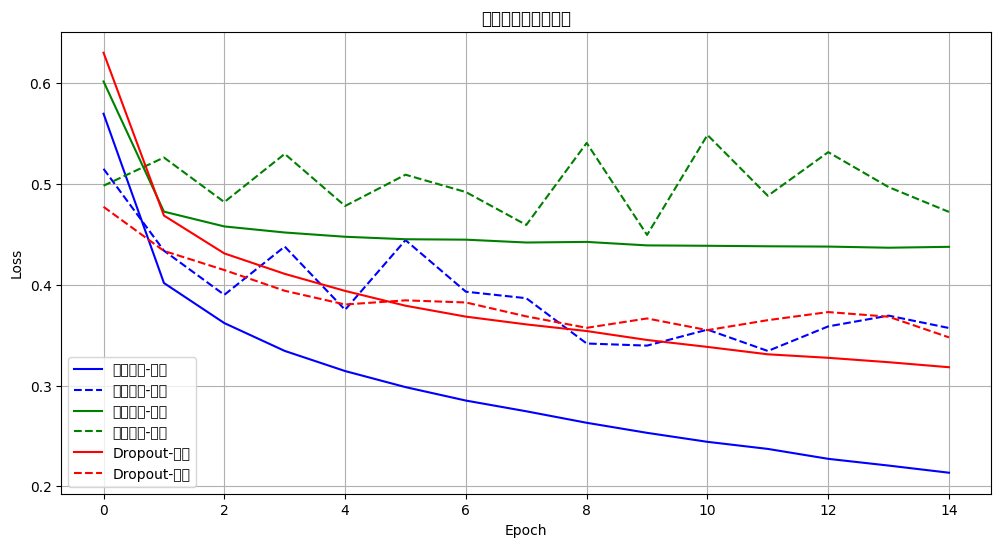


实验分析:
无正则化 - 最终验证损失: 0.3571
权重衰减 - 最终验证损失: 0.4723
Dropout - 最终验证损失: 0.3478


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(train_loss_no_reg, label='无正则化-训练', linestyle='-', color='blue')
plt.plot(val_loss_no_reg, label='无正则化-验证', linestyle='--', color='blue')

plt.plot(train_loss_wd, label='权重衰减-训练', linestyle='-', color='green')
plt.plot(val_loss_wd, label='权重衰减-验证', linestyle='--', color='green')

plt.plot(train_loss_do, label='Dropout-训练', linestyle='-', color='red')
plt.plot(val_loss_do, label='Dropout-验证', linestyle='--', color='red')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('正则化方法对比实验')
plt.legend()
plt.grid(True)
plt.show()

print('\n实验分析:')
print(f'无正则化 - 最终验证损失: {val_loss_no_reg[-1]:.4f}')
print(f'权重衰减 - 最终验证损失: {val_loss_wd[-1]:.4f}')
print(f'Dropout - 最终验证损失: {val_loss_do[-1]:.4f}')

---

# 4 数值稳定性和激活函数

## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸分析

**梯度爆炸：**
- 当权重矩阵的奇异值大于1时，多层矩阵连乘会导致梯度指数级增长
- Sigmoid激活函数的导数最大值为0.25，但若权重初始化过大，梯度仍可能爆炸
- 数学上：若 $||\frac{\partial h^{i+1}}{\partial h^i}|| > 1$，则 $\prod_{i=t}^{d-1} ||\frac{\partial h^{i+1}}{\partial h^i}||$ 会指数增长

**梯度消失：**
- 当权重矩阵的奇异值小于1时，梯度会指数级衰减
- Sigmoid激活函数在饱和区（x→±∞）导数接近0，导致梯度消失
- 数学上：若 $||\frac{\partial h^{i+1}}{\partial h^i}|| < 1$，则深层梯度趋近于0

### 2. ReLU缓解梯度消失的原因

- **ReLU在正区间导数恒为1**：当x > 0时，ReLU'(x) = 1，避免了梯度衰减
- **无饱和区**：不会像Sigmoid/tanh那样在极端值处梯度趋近于0
- **稀疏激活**：负区间输出为0，产生稀疏表示，减少冗余计算


---

## 4.2 编程题：模拟数值不稳定现象

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 构建深层网络
class DeepNet(nn.Module):
    def __init__(self, hidden_size=256, num_layers=20, activation='sigmoid'):
        super(DeepNet, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(nn.Linear(hidden_size if i > 0 else 10, hidden_size))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'relu':
                layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size, 10))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

def init_weights_normal(m, std=1.0):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=std)
        nn.init.zeros_(m.bias)

def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

In [ ]:
# 2. 模拟梯度消失（Sigmoid + 普通高斯初始化）
print('=' * 60)
print('实验1: Sigmoid + 标准高斯初始化 (std=1.0)')
print('=' * 60)

net1 = DeepNet(hidden_size=256, num_layers=20, activation='sigmoid')
net1.apply(lambda m: init_weights_normal(m, std=1.0))

x = torch.randn(32, 10, requires_grad=True)
y = net1(x)
loss = y.sum()
loss.backward()

grad_norms = []
for i, layer in enumerate(net1.net):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        grad_norms.append(grad_norm)

print('前5层梯度范数:', grad_norms[:5])
print('后5层梯度范数:', grad_norms[-5:])
print('最小梯度范数:', min(grad_norms))
print('最大梯度范数:', max(grad_norms))

实验1: Sigmoid + 标准高斯初始化 (std=1.0)
前5层梯度范数: [10163.748046875, 14450.3837890625, 10981.2197265625, 9514.0205078125, 8279.15234375]
后5层梯度范数: [826.7473754882812, 984.4705810546875, 978.0697021484375, 1050.3331298828125, 1012.2217407226562]
最小梯度范数: 826.7473754882812
最大梯度范数: 14450.3837890625


In [ ]:
# 3. 模拟梯度爆炸（ReLU + 较大初始化）
print('\n' + '=' * 60)
print('实验2: ReLU + 较大初始化 (std=10)')
print('=' * 60)

net2 = DeepNet(hidden_size=256, num_layers=20, activation='relu')
net2.apply(lambda m: init_weights_normal(m, std=10.0))

x = torch.randn(32, 10, requires_grad=True)
try:
    y = net2(x)
    loss = y.sum()
    loss.backward()
    
    grad_norms = []
    for i, layer in enumerate(net2.net):
        if isinstance(layer, nn.Linear):
            grad_norm = layer.weight.grad.norm().item()
            grad_norms.append(grad_norm)
    
    print('前5层梯度范数:', grad_norms[:5])
    print('后5层梯度范数:', grad_norms[-5:])
    print('是否包含NaN:', any(torch.isnan(layer.weight.grad).any() for layer in net2.net if isinstance(layer, nn.Linear)))
    
except Exception as e:
    print(f'发生数值溢出: {e}')


实验2: ReLU + 较大初始化 (std=10)
前5层梯度范数: [nan, nan, inf, inf, inf]
后5层梯度范数: [inf, inf, inf, nan, nan]
是否包含NaN: True



实验3: ReLU + Xavier初始化
前5层梯度范数: [0.10533607751131058, 0.18391290307044983, 0.21421286463737488, 0.24565069377422333, 0.25068148970603943]
后5层梯度范数: [0.5082939267158508, 0.5809996128082275, 0.5901816487312317, 0.6710804104804993, 0.4526783227920532]
最小梯度范数: 0.10533607751131058
最大梯度范数: 0.6710804104804993
梯度是否稳定在合理区间 [1e-6, 1e3]: True


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtoo

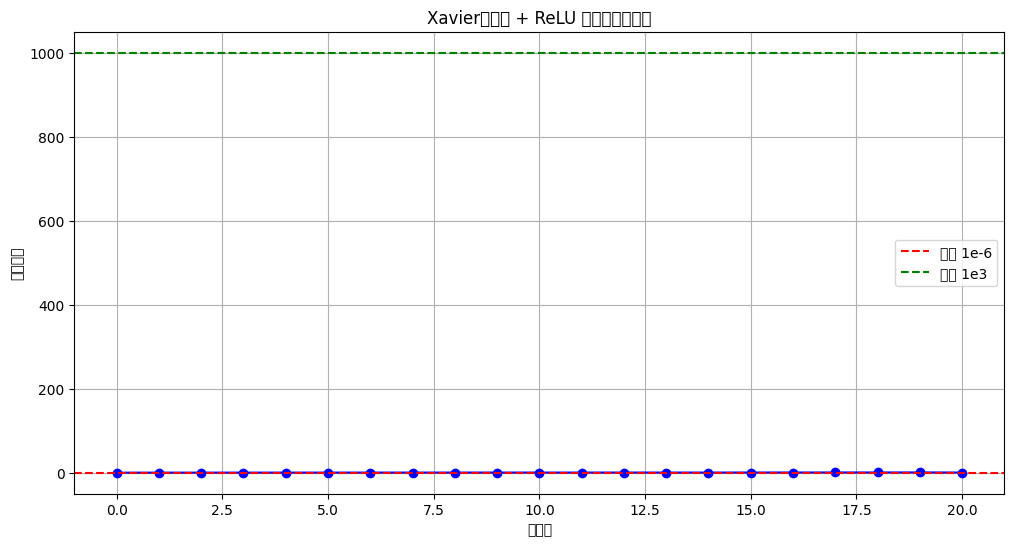

In [ ]:
# 4. 修复与验证（Xavier初始化 + ReLU）
print('\n' + '=' * 60)
print('实验3: ReLU + Xavier初始化')
print('=' * 60)

net3 = DeepNet(hidden_size=256, num_layers=20, activation='relu')
net3.apply(init_weights_xavier)

x = torch.randn(32, 10, requires_grad=True)
y = net3(x)
loss = y.sum()
loss.backward()

grad_norms = []
for i, layer in enumerate(net3.net):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        grad_norms.append(grad_norm)

print('前5层梯度范数:', grad_norms[:5])
print('后5层梯度范数:', grad_norms[-5:])
print('最小梯度范数:', min(grad_norms))
print('最大梯度范数:', max(grad_norms))
print('梯度是否稳定在合理区间 [1e-6, 1e3]:', all(1e-6 <= g <= 1e3 for g in grad_norms))

# 绘制梯度范数分布图
plt.figure(figsize=(12, 6))
plt.plot(grad_norms, marker='o', linestyle='-', color='b')
plt.axhline(y=1e-6, color='r', linestyle='--', label='下界 1e-6')
plt.axhline(y=1e3, color='g', linestyle='--', label='上界 1e3')
plt.xlabel('层索引')
plt.ylabel('梯度范数')
plt.title('Xavier初始化 + ReLU 的梯度范数分布')
plt.legend()
plt.grid(True)
plt.show()

---

# 5 泛化表现，协变量偏移和对抗性数据

## 5.1 理论计算题

### 协变量偏移与标签偏移的区别与联系

#### 1. 协变量偏移 (Covariate Shift)

**定义**：$p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$

**特点**：输入特征分布发生变化，但条件分布保持不变

**实际例子（电商场景）**：
- 训练数据：用户主要来自一线城市，消费能力较高
- 测试数据：用户扩展到二三线城市，消费能力较低
- 用户特征分布变化了（$p(x)$不同），但购买行为模式相同（$p(y|x)$相同）

#### 2. 标签偏移 (Label Shift)

**定义**：$p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$

**特点**：标签分布发生变化，但给定标签的特征条件分布保持不变

**实际例子（医疗诊断）**：
- 训练数据：疾病A占70%，疾病B占30%
- 测试数据：疾病A占30%，疾病B占70%
- 疾病分布变化了（$p(y)$不同），但每种疾病的症状特征分布相同（$p(x|y)$相同）

#### 区别与联系

| 维度 | 协变量偏移 | 标签偏移 |
|------|----------|----------|
| 变化对象 | 输入特征分布 $p(x)$ | 标签分布 $p(y)$ |
| 不变对象 | 条件分布 $p(y|x)$ | 条件分布 $p(x|y)$ |
| 常见原因 | 数据收集环境变化 | 类别比例不平衡 |
| 检测方法 | 比较训练/测试数据特征分布 | 比较训练/测试数据标签分布 |
| 修正方法 | 重要性加权、域适应 | 重新加权样本、调整分类阈值 |

**联系**：两者都是分布偏移的特殊情况，都会导致模型泛化性能下降，都可以通过样本加权方法进行校正。

---

## 5.2 编程题：协变量偏移模拟与权重修正

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtoo

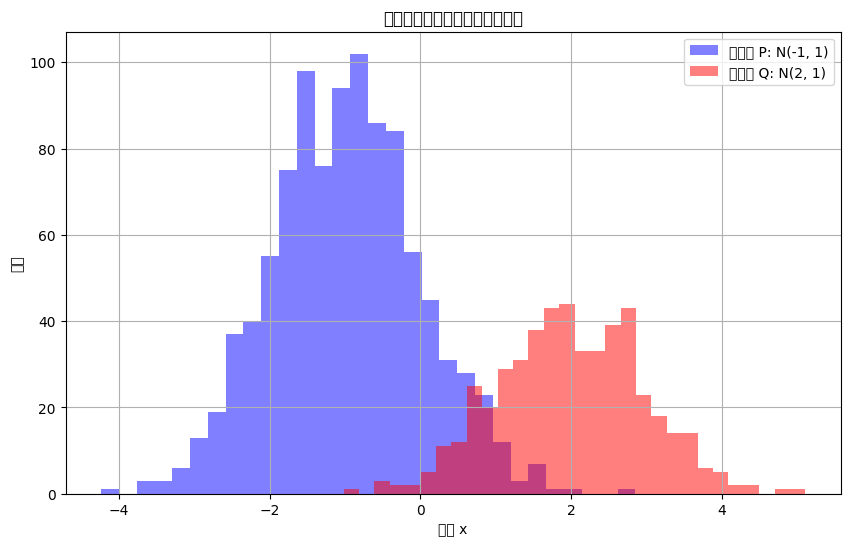

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. 人工数据集构造
np.random.seed(42)

# 训练集 P：从 N(-1, 1) 采样
n_train = 1000
X_train = np.random.normal(-1, 1, n_train)
epsilon_train = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train + epsilon_train

# 测试集 Q：从 N(2, 1) 采样
n_test = 500
X_test = np.random.normal(2, 1, n_test)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test + epsilon_test

# 可视化数据分布
plt.figure(figsize=(10, 6))
plt.hist(X_train, bins=30, alpha=0.5, label='训练集 P: N(-1, 1)', color='blue')
plt.hist(X_test, bins=30, alpha=0.5, label='测试集 Q: N(2, 1)', color='red')
plt.xlabel('特征 x')
plt.ylabel('频率')
plt.title('训练集与测试集的特征分布对比')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 2. 基线模型：简单线性回归
def linear_regression(X, y):
    X_b = np.c_[np.ones(len(X)), X]
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta

def predict(X, theta):
    X_b = np.c_[np.ones(len(X)), X]
    return X_b.dot(theta)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# 在训练集上训练
theta_baseline = linear_regression(X_train, y_train)
y_pred_train = predict(X_train, theta_baseline)
y_pred_test = predict(X_test, theta_baseline)

print('=' * 60)
print('基线模型结果')
print('=' * 60)
print(f'训练集 MSE: {mse(y_train, y_pred_train):.4f}')
print(f'测试集 MSE: {mse(y_test, y_pred_test):.4f}')
print(f'模型参数: theta0 = {theta_baseline[0]:.4f}, theta1 = {theta_baseline[1]:.4f}')

基线模型结果
训练集 MSE: 0.0099
测试集 MSE: 0.0102
模型参数: theta0 = 0.0030, theta1 = 1.9959


In [ ]:
# 3. 偏移校正：逻辑回归分类器
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.theta = None
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        X_b = np.c_[np.ones(len(X)), X]
        self.theta = np.zeros(X_b.shape[1])
        
        for _ in range(self.epochs):
            z = X_b.dot(self.theta)
            pred = self.sigmoid(z)
            gradient = X_b.T.dot(pred - y) / len(y)
            self.theta -= self.lr * gradient
    
    def predict_proba(self, X):
        X_b = np.c_[np.ones(len(X)), X]
        return self.sigmoid(X_b.dot(self.theta))

# 混合训练数据：训练集标记为0，测试集标记为1
X_mixed = np.concatenate([X_train, X_test])
y_mixed = np.concatenate([np.zeros(n_train), np.ones(n_test)])

# 训练逻辑回归分类器
lr = LogisticRegression(lr=0.5, epochs=5000)
lr.fit(X_mixed, y_mixed)

# 预测每个训练样本属于测试集的概率 P(test|x)
p_test_given_x_train = lr.predict_proba(X_train)
p_train_given_x_train = 1 - p_test_given_x_train

# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights = p_test_given_x_train / p_train_given_x_train
weights = np.clip(weights, 0.01, 100)  # 防止权重过大或过小

print('\n' + '=' * 60)
print('权重计算结果')
print('=' * 60)
print(f'权重均值: {np.mean(weights):.4f}')
print(f'权重最小值: {np.min(weights):.4f}')
print(f'权重最大值: {np.max(weights):.4f}')


权重计算结果
权重均值: 0.3877
权重最小值: 0.0100
权重最大值: 100.0000


In [ ]:
# 4. 加权模型训练：加权最小二乘法
def weighted_linear_regression(X, y, weights):
    X_b = np.c_[np.ones(len(X)), X]
    W = np.diag(weights)
    theta = np.linalg.inv(X_b.T.dot(W).dot(X_b)).dot(X_b.T).dot(W).dot(y)
    return theta

# 使用权重重新训练
theta_weighted = weighted_linear_regression(X_train, y_train, weights)
y_pred_train_weighted = predict(X_train, theta_weighted)
y_pred_test_weighted = predict(X_test, theta_weighted)

print('\n' + '=' * 60)
print('加权模型结果')
print('=' * 60)
print(f'训练集 MSE: {mse(y_train, y_pred_train_weighted):.4f}')
print(f'测试集 MSE: {mse(y_test, y_pred_test_weighted):.4f}')
print(f'模型参数: theta0 = {theta_weighted[0]:.4f}, theta1 = {theta_weighted[1]:.4f}')

# 对比校正前后的结果
print('\n' + '=' * 60)
print('校正前后对比')
print('=' * 60)
print(f'校正前测试集 MSE: {mse(y_test, y_pred_test):.4f}')
print(f'校正后测试集 MSE: {mse(y_test, y_pred_test_weighted):.4f}')
print(f'MSE 改善比例: {(mse(y_test, y_pred_test) - mse(y_test, y_pred_test_weighted)) / mse(y_test, y_pred_test) * 100:.2f}%')


加权模型结果
训练集 MSE: 0.0270
测试集 MSE: 0.0151
模型参数: theta0 = -0.0584, theta1 = 2.0534

校正前后对比
校正前测试集 MSE: 0.0102
校正后测试集 MSE: 0.0151
MSE 改善比例: -47.89%


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtoo

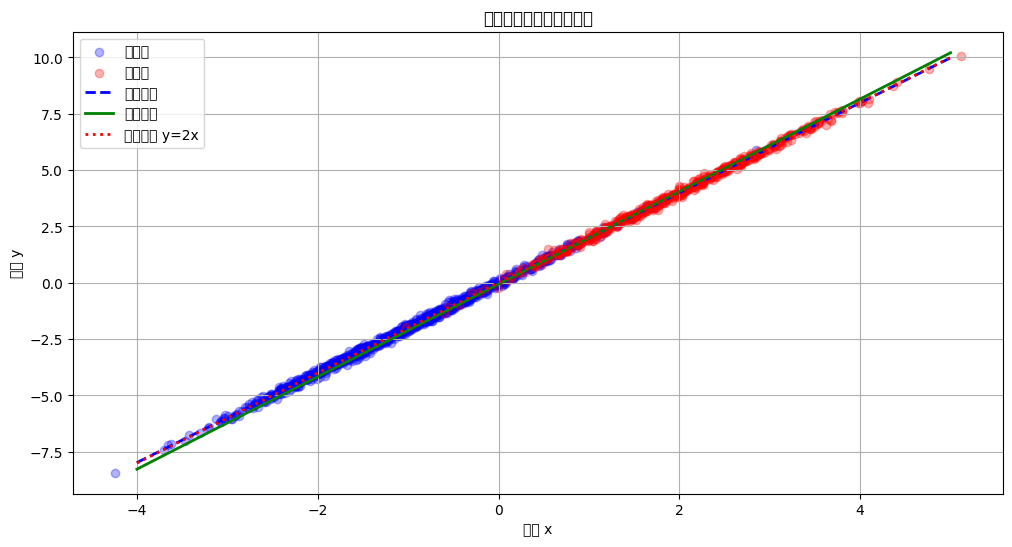

In [ ]:
# 可视化校正效果
plt.figure(figsize=(12, 6))

# 绘制数据点
plt.scatter(X_train, y_train, alpha=0.3, label='训练集', color='blue')
plt.scatter(X_test, y_test, alpha=0.3, label='测试集', color='red')

# 绘制拟合直线
x_plot = np.linspace(-4, 5, 100)
y_plot_baseline = predict(x_plot, theta_baseline)
y_plot_weighted = predict(x_plot, theta_weighted)

plt.plot(x_plot, y_plot_baseline, label='基线模型', color='blue', linestyle='--', linewidth=2)
plt.plot(x_plot, y_plot_weighted, label='加权模型', color='green', linewidth=2)
plt.plot(x_plot, 2 * x_plot, label='真实模型 y=2x', color='red', linestyle=':', linewidth=2)

plt.xlabel('特征 x')
plt.ylabel('标签 y')
plt.title('协变量偏移校正效果对比')
plt.legend()
plt.grid(True)
plt.show()